# TP1 - Grupo 2
## Taller de Programación - Maestría en Economía Aplicada UBA

Autores:
Andrea Chasi
Pablo Ortiz
Santiago Soler

Grupo 2

Maestría en Economía Aplicada

Universidad de Buenos Aires

Julio 2026

Este notebook contiene todo el procesamiento realizado para el Trabajo Práctico N°1.

Se reproducen íntegramente los resultados incluidos en el informe final.

## 1. Carga de datos

In [34]:
from google.colab import files
uploaded = files.upload()

Saving usu_individual_T424.xlsx to usu_individual_T424 (2).xlsx
Saving usu_individual_T425.xlsx to usu_individual_T425 (2).xlsx


## 2. Selección de variables

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

variables = [
    'CODUSU','ANO4','TRIMESTRE','NRO_HOGAR','COMPONENTE',
    'PONDERA','AGLOMERADO','CH04','CH06','CH07','CH08',
    'NIVEL_ED','ESTADO','CAT_OCUP','PP04C','PP04D_COD',
    'PP07H','PP07I','PP07J','PP07K','PP08D1','PP08F1',
    'P21','P47T'
]

eph24 = pd.read_excel("usu_individual_T424.xlsx")
eph25 = pd.read_excel("usu_individual_T425.xlsx")

eph24_sel = eph24[variables].copy()
eph25_sel = eph25[variables].copy()

for df in [eph24_sel, eph25_sel]:
    df["P21"] = df["P21"].replace(-9, np.nan)
    df["P47T"] = df["P47T"].replace(-9, np.nan)

respondieron24 = eph24_sel[eph24_sel["ESTADO"] != 0].copy()
respondieron25 = eph25_sel[eph25_sel["ESTADO"] != 0].copy()

norespondieron24 = eph24_sel[eph24_sel["ESTADO"] == 0].copy()
norespondieron25 = eph25_sel[eph25_sel["ESTADO"] == 0].copy()

ocupados24 = respondieron24[respondieron24["ESTADO"] == 1].copy()
ocupados25 = respondieron25[respondieron25["ESTADO"] == 1].copy()

for df in [ocupados24, ocupados25]:
    df["mujer"] = (df["CH04"] == 2).astype(int)
    df["casado"] = ((df["CH07"] == 1) | (df["CH07"] == 2)).astype(int)
    df["universitario"] = (df["NIVEL_ED"] >= 6).astype(int)
    df["asalariado"] = (df["CAT_OCUP"] == 3).astype(int)
    df["informal"] = np.where(
        (df["CAT_OCUP"] == 3) & (df["PP07H"] == 2),
        1,
        0
    )
    df["condicion_laboral"] = np.where(
        df["informal"] == 1,
        "Informal",
        "Formal"
    )

print("Ocupados 2024:", ocupados24.shape)
print("Ocupados 2025:", ocupados25.shape)

Ocupados 2024: (21132, 30)
Ocupados 2025: (19698, 30)


In [36]:
ocupados25_graf = ocupados25[
    (ocupados25["P21"] <= ocupados25["P21"].quantile(0.99)) &
    (ocupados25["P47T"] <= ocupados25["P47T"].quantile(0.99))
].copy()

ocupados24_graf = ocupados24[
    (ocupados24["P21"] <= ocupados24["P21"].quantile(0.99)) &
    (ocupados24["P47T"] <= ocupados24["P47T"].quantile(0.99))
].copy()

## 3. Distribución de ingresos laborales (Histogramas + Kernel)

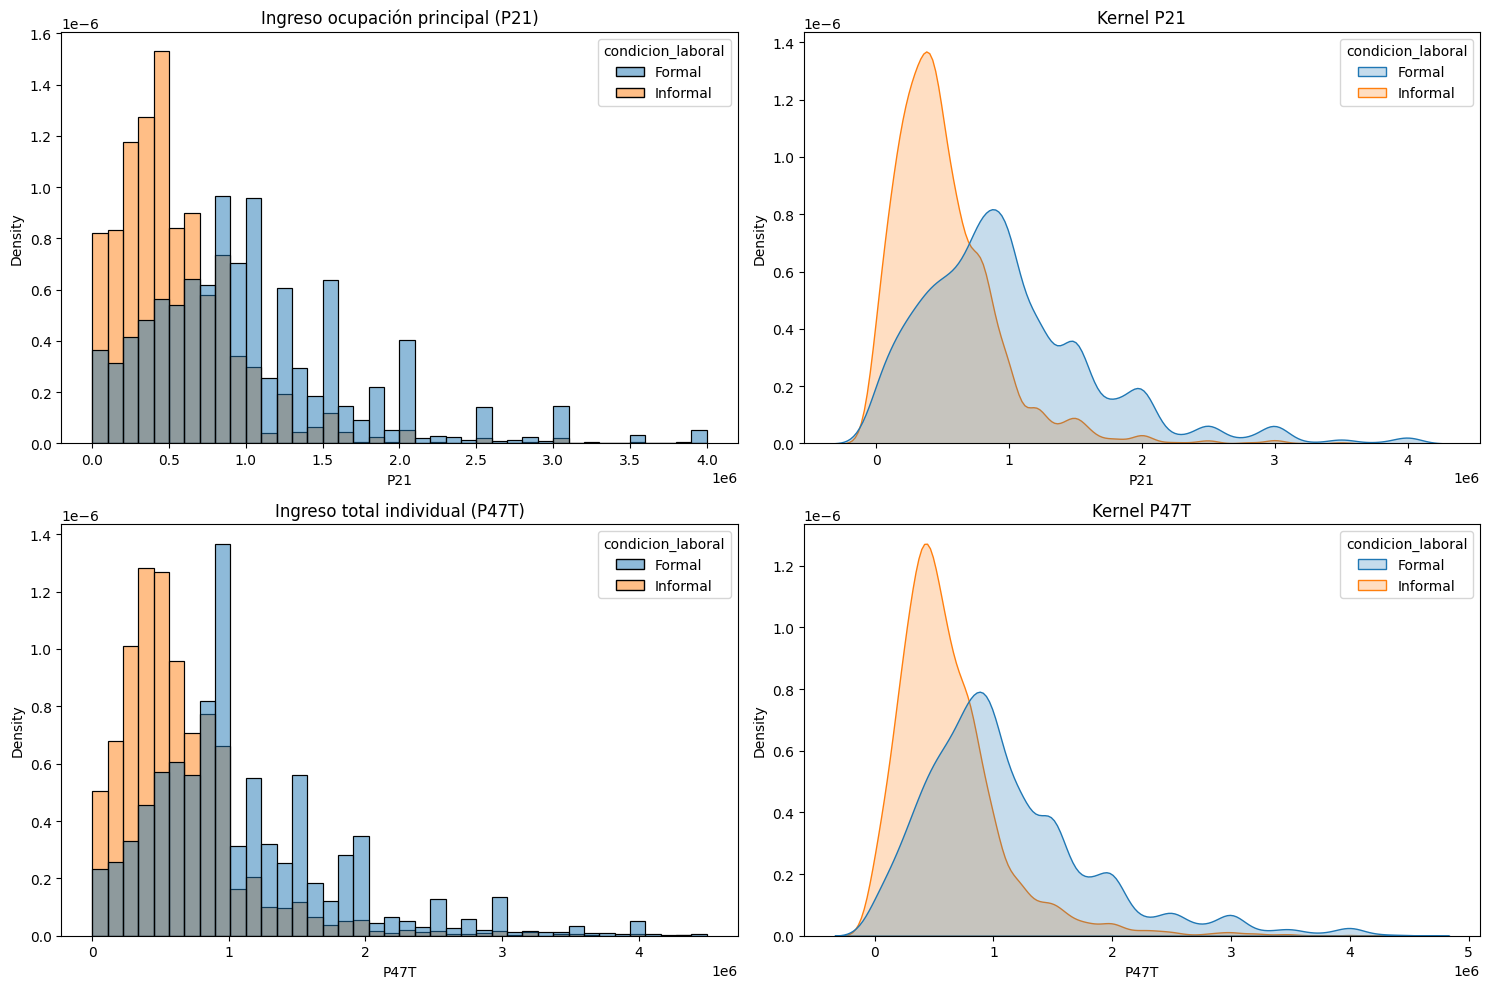

In [37]:
fig, ax = plt.subplots(2,2, figsize=(15,10))

# Histograma P21
sns.histplot(
    data=ocupados25_graf,
    x="P21",
    hue="condicion_laboral",
    bins=40,
    stat="density",
    common_norm=False,
    ax=ax[0,0]
)

ax[0,0].set_title("Ingreso ocupación principal (P21)")

# Kernel P21
sns.kdeplot(
    data=ocupados25_graf,
    x="P21",
    hue="condicion_laboral",
    fill=True,
    common_norm=False,
    ax=ax[0,1]
)

ax[0,1].set_title("Kernel P21")

# Histograma P47T
sns.histplot(
    data=ocupados25_graf,
    x="P47T",
    hue="condicion_laboral",
    bins=40,
    stat="density",
    common_norm=False,
    ax=ax[1,0]
)

ax[1,0].set_title("Ingreso total individual (P47T)")

# Kernel P47T
sns.kdeplot(
    data=ocupados25_graf,
    x="P47T",
    hue="condicion_laboral",
    fill=True,
    common_norm=False,
    ax=ax[1,1]
)

ax[1,1].set_title("Kernel P47T")

plt.tight_layout()

plt.savefig("Grafico_Ingresos_2025.png", dpi=300)

plt.show()

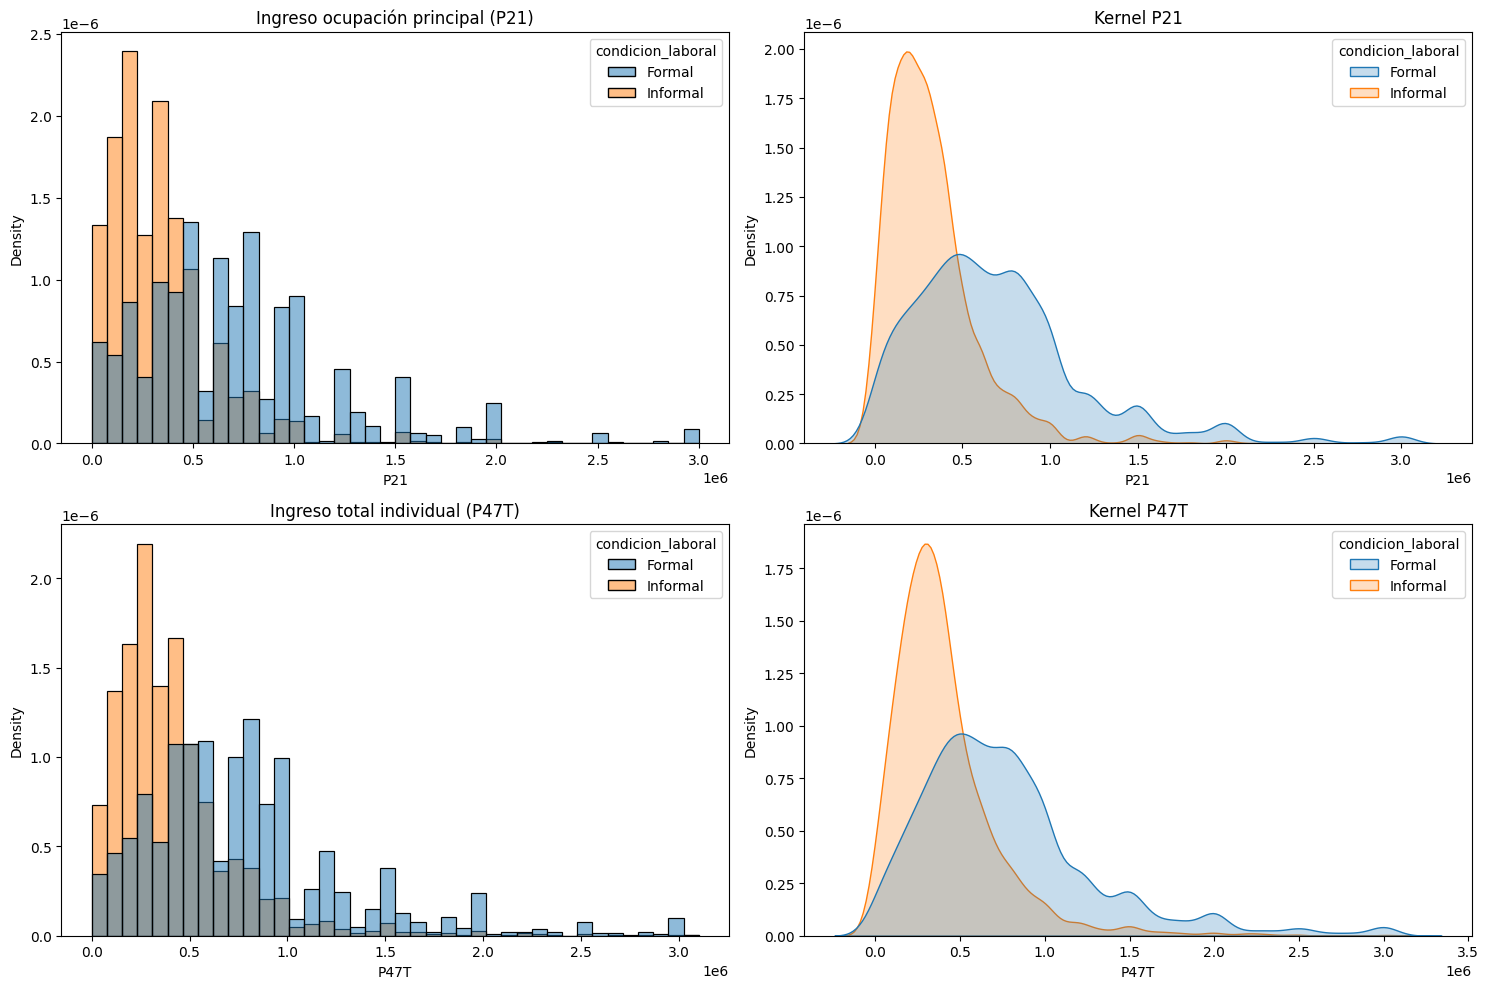

In [38]:
fig, ax = plt.subplots(2,2, figsize=(15,10))

# Histograma P21
sns.histplot(
    data=ocupados24_graf,
    x="P21",
    hue="condicion_laboral",
    bins=40,
    stat="density",
    common_norm=False,
    ax=ax[0,0]
)

ax[0,0].set_title("Ingreso ocupación principal (P21)")

# Kernel P21
sns.kdeplot(
    data=ocupados24_graf,
    x="P21",
    hue="condicion_laboral",
    fill=True,
    common_norm=False,
    ax=ax[0,1]
)

ax[0,1].set_title("Kernel P21")

# Histograma P47T
sns.histplot(
    data=ocupados24_graf,
    x="P47T",
    hue="condicion_laboral",
    bins=40,
    stat="density",
    common_norm=False,
    ax=ax[1,0]
)

ax[1,0].set_title("Ingreso total individual (P47T)")

# Kernel P47T
sns.kdeplot(
    data=ocupados24_graf,
    x="P47T",
    hue="condicion_laboral",
    fill=True,
    common_norm=False,
    ax=ax[1,1]
)

ax[1,1].set_title("Kernel P47T")

plt.tight_layout()

plt.savefig("Grafico_Ingresos_2024.png", dpi=300)

plt.show()

In [39]:
ocupados24_graf["Condicion laboral"] = ocupados24_graf["condicion_laboral"]
ocupados25_graf["Condicion laboral"] = ocupados25_graf["condicion_laboral"]

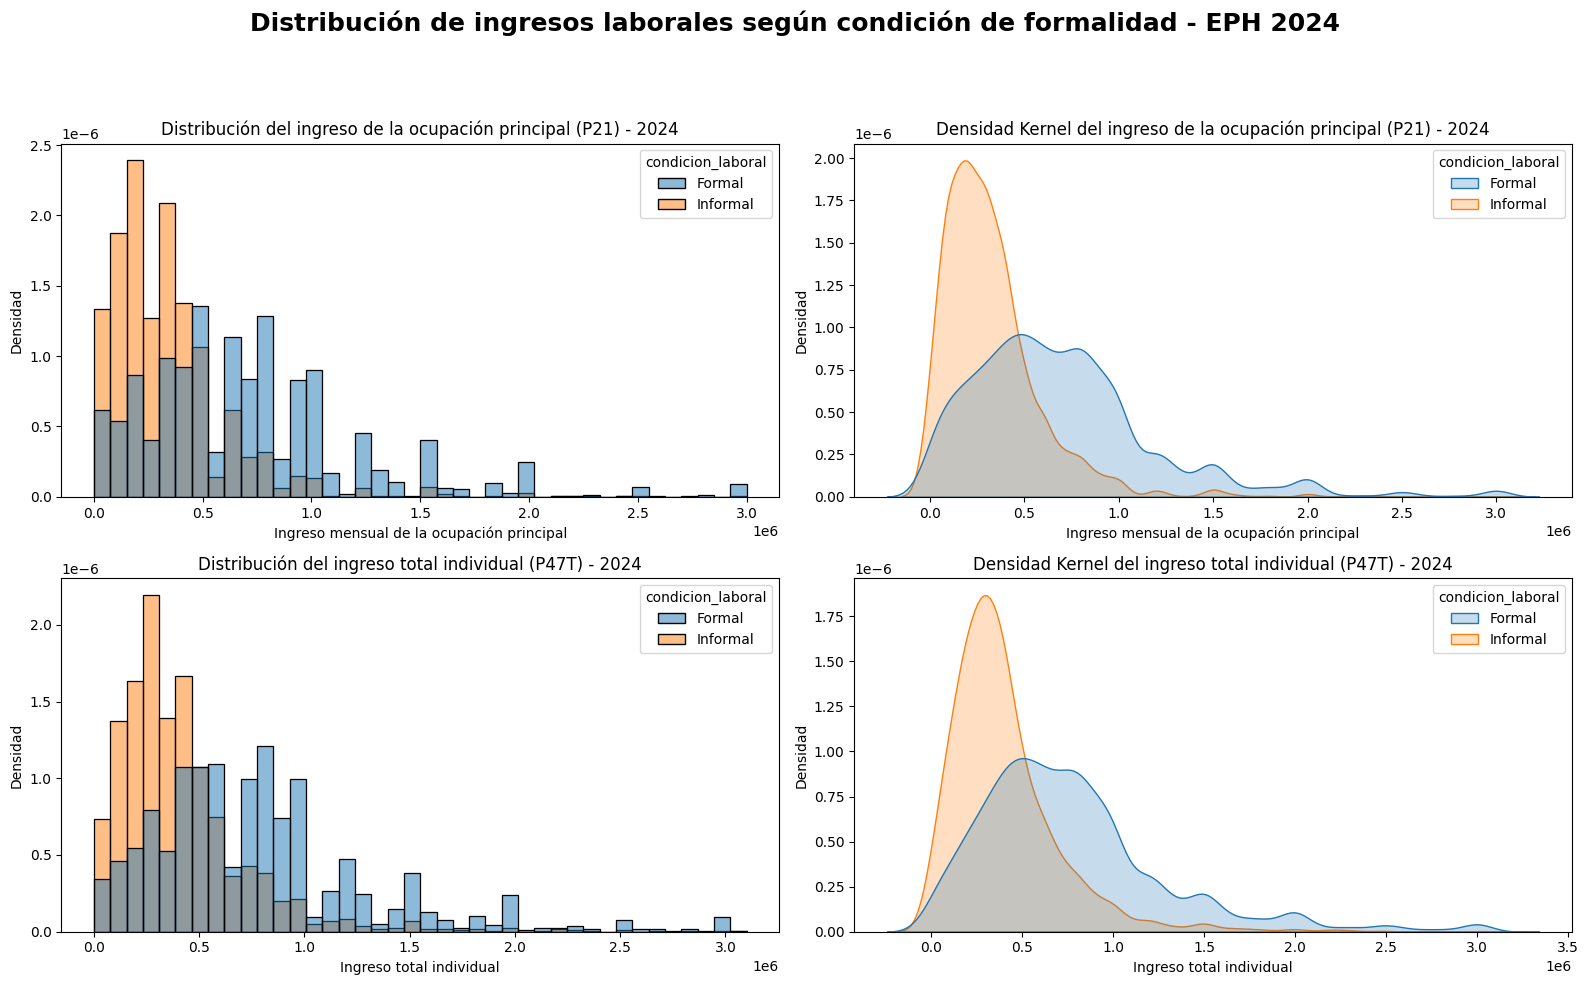

In [40]:
# Gráfico final 2024: ingresos según condición laboral

ocupados24_graf = ocupados24[
    (ocupados24["P21"] >= 0) &
    (ocupados24["P47T"] >= 0) &
    (ocupados24["P21"] <= ocupados24["P21"].quantile(0.99)) &
    (ocupados24["P47T"] <= ocupados24["P47T"].quantile(0.99))
].copy()

fig, ax = plt.subplots(2, 2, figsize=(16, 10))

fig.suptitle(
    "Distribución de ingresos laborales según condición de formalidad - EPH 2024",
    fontsize=18,
    fontweight="bold"
)

sns.histplot(data=ocupados24_graf, x="P21", hue="condicion_laboral",
             bins=40, stat="density", common_norm=False, ax=ax[0,0])
ax[0,0].set_title("Distribución del ingreso de la ocupación principal (P21) - 2024")
ax[0,0].set_xlabel("Ingreso mensual de la ocupación principal")
ax[0,0].set_ylabel("Densidad")

sns.kdeplot(data=ocupados24_graf, x="P21", hue="condicion_laboral",
            fill=True, common_norm=False, ax=ax[0,1])
ax[0,1].set_title("Densidad Kernel del ingreso de la ocupación principal (P21) - 2024")
ax[0,1].set_xlabel("Ingreso mensual de la ocupación principal")
ax[0,1].set_ylabel("Densidad")

sns.histplot(data=ocupados24_graf, x="P47T", hue="condicion_laboral",
             bins=40, stat="density", common_norm=False, ax=ax[1,0])
ax[1,0].set_title("Distribución del ingreso total individual (P47T) - 2024")
ax[1,0].set_xlabel("Ingreso total individual")
ax[1,0].set_ylabel("Densidad")

sns.kdeplot(data=ocupados24_graf, x="P47T", hue="condicion_laboral",
            fill=True, common_norm=False, ax=ax[1,1])
ax[1,1].set_title("Densidad Kernel del ingreso total individual (P47T) - 2024")
ax[1,1].set_xlabel("Ingreso total individual")
ax[1,1].set_ylabel("Densidad")

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Figura_1_Distribucion_Ingresos_2024.png", dpi=300)
plt.show()

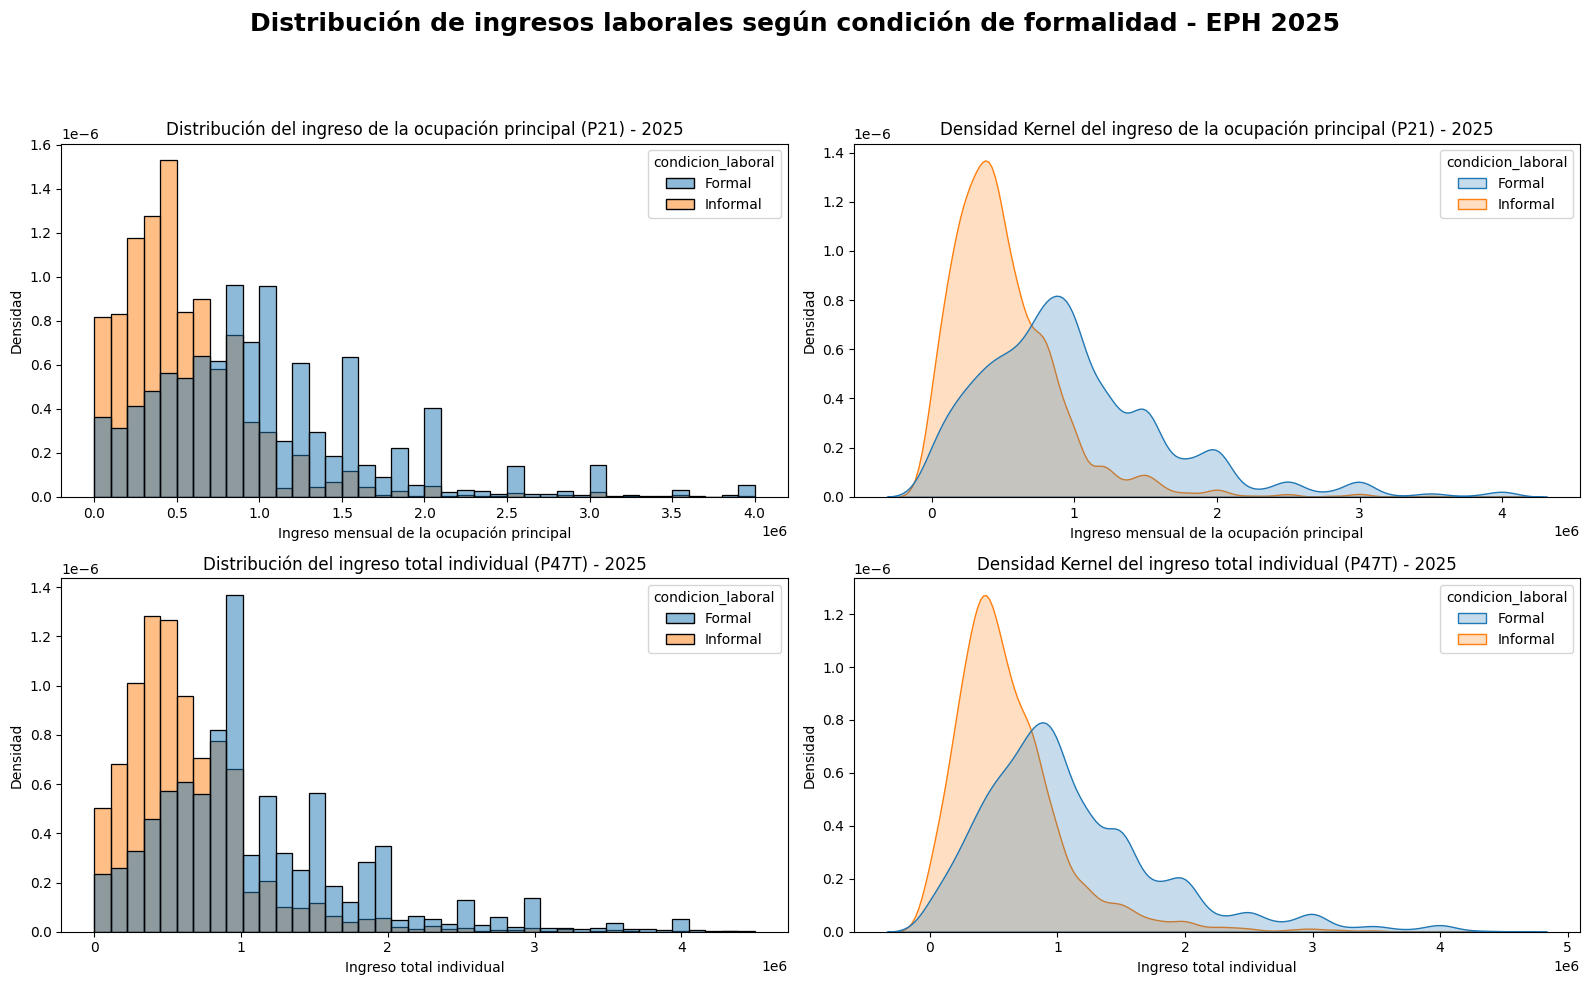

In [41]:
# Gráfico final 2025: ingresos según condición laboral

ocupados25_graf = ocupados25[
    (ocupados25["P21"] >= 0) &
    (ocupados25["P47T"] >= 0) &
    (ocupados25["P21"] <= ocupados25["P21"].quantile(0.99)) &
    (ocupados25["P47T"] <= ocupados25["P47T"].quantile(0.99))
].copy()

fig, ax = plt.subplots(2, 2, figsize=(16, 10))

fig.suptitle(
    "Distribución de ingresos laborales según condición de formalidad - EPH 2025",
    fontsize=18,
    fontweight="bold"
)

sns.histplot(data=ocupados25_graf, x="P21", hue="condicion_laboral",
             bins=40, stat="density", common_norm=False, ax=ax[0,0])
ax[0,0].set_title("Distribución del ingreso de la ocupación principal (P21) - 2025")
ax[0,0].set_xlabel("Ingreso mensual de la ocupación principal")
ax[0,0].set_ylabel("Densidad")

sns.kdeplot(data=ocupados25_graf, x="P21", hue="condicion_laboral",
            fill=True, common_norm=False, ax=ax[0,1])
ax[0,1].set_title("Densidad Kernel del ingreso de la ocupación principal (P21) - 2025")
ax[0,1].set_xlabel("Ingreso mensual de la ocupación principal")
ax[0,1].set_ylabel("Densidad")

sns.histplot(data=ocupados25_graf, x="P47T", hue="condicion_laboral",
             bins=40, stat="density", common_norm=False, ax=ax[1,0])
ax[1,0].set_title("Distribución del ingreso total individual (P47T) - 2025")
ax[1,0].set_xlabel("Ingreso total individual")
ax[1,0].set_ylabel("Densidad")

sns.kdeplot(data=ocupados25_graf, x="P47T", hue="condicion_laboral",
            fill=True, common_norm=False, ax=ax[1,1])
ax[1,1].set_title("Densidad Kernel del ingreso total individual (P47T) - 2025")
ax[1,1].set_xlabel("Ingreso total individual")
ax[1,1].set_ylabel("Densidad")

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Figura_2_Distribucion_Ingresos_2025.png", dpi=300)
plt.show()

## 4. Estadísticos descriptivos

In [42]:
tabla_final = pd.DataFrame({
    "Indicador": [
        "Ocupados",
        "Edad promedio",
        "Mujeres (%)",
        "Casados/unidos (%)",
        "Universitarios (%)",
        "Asalariados (%)",
        "Informales (%)",
        "Ingreso total promedio"
    ],
    "2024": [
        len(ocupados24),
        ocupados24["CH06"].mean(),
        ocupados24["mujer"].mean()*100,
        ocupados24["casado"].mean()*100,
        ocupados24["universitario"].mean()*100,
        ocupados24["asalariado"].mean()*100,
        ocupados24["informal"].mean()*100,
        ocupados24["P47T"].mean()
    ],
    "2025": [
        len(ocupados25),
        ocupados25["CH06"].mean(),
        ocupados25["mujer"].mean()*100,
        ocupados25["casado"].mean()*100,
        ocupados25["universitario"].mean()*100,
        ocupados25["asalariado"].mean()*100,
        ocupados25["informal"].mean()*100,
        ocupados25["P47T"].mean()
    ]
})

tabla_final["Variación %"] = ((tabla_final["2025"] - tabla_final["2024"]) / tabla_final["2024"]) * 100

tabla_final = tabla_final.round(2)
tabla_final

,Indicador,2024,2025,Variación %
0,Ocupados,21132.00,19698.00,-6.79
1,Edad promedio,41.31,41.86,1.34
2,Mujeres (%),45.00,45.49,1.09
3,Casados/unidos (%),53.54,53.42,-0.22
4,Universitarios (%),24.39,23.93,-1.92
5,Asalariados (%),72.36,70.78,-2.18
6,Informales (%),26.33,26.03,-1.14
7,Ingreso total promedio,715121.32,1040594.84,45.51


## 5. Ajuste de ingresos 2024 a precios de 2025

In [43]:
# Ajuste monetario de ingresos 2024 a pesos de 2025T4
# Fuente: IPC INDEC, variación acumulada 2025 = 31,5%

factor_ipc_2025 = 1.315

ocupados24["P21_2025"] = ocupados24["P21"] * factor_ipc_2025
ocupados24["P47T_2025"] = ocupados24["P47T"] * factor_ipc_2025

ocupados25["P21_2025"] = ocupados25["P21"]
ocupados25["P47T_2025"] = ocupados25["P47T"]

respondieron24["P21_2025"] = respondieron24["P21"] * factor_ipc_2025
respondieron24["P47T_2025"] = respondieron24["P47T"] * factor_ipc_2025

respondieron25["P21_2025"] = respondieron25["P21"]
respondieron25["P47T_2025"] = respondieron25["P47T"]

print("Ajuste aplicado con factor:", factor_ipc_2025)

Ajuste aplicado con factor: 1.315


## 6. Estadísticos descriptivos con ajuste por IPC

In [44]:
tabla_final_ajustada = pd.DataFrame({
    "Indicador": [
        "Ocupados",
        "Edad promedio",
        "Mujeres (%)",
        "Casados/unidos (%)",
        "Universitarios (%)",
        "Asalariados (%)",
        "Informales (%)",
        "Ingreso total promedio ajustado"
    ],
    "2024 ajustado": [
        len(ocupados24),
        ocupados24["CH06"].mean(),
        ocupados24["mujer"].mean()*100,
        ocupados24["casado"].mean()*100,
        ocupados24["universitario"].mean()*100,
        ocupados24["asalariado"].mean()*100,
        ocupados24["informal"].mean()*100,
        ocupados24["P47T_2025"].mean()
    ],
    "2025": [
        len(ocupados25),
        ocupados25["CH06"].mean(),
        ocupados25["mujer"].mean()*100,
        ocupados25["casado"].mean()*100,
        ocupados25["universitario"].mean()*100,
        ocupados25["asalariado"].mean()*100,
        ocupados25["informal"].mean()*100,
        ocupados25["P47T_2025"].mean()
    ]
})

tabla_final_ajustada["Variación %"] = (
    (tabla_final_ajustada["2025"] - tabla_final_ajustada["2024 ajustado"]) /
    tabla_final_ajustada["2024 ajustado"]
) * 100

tabla_final_ajustada = tabla_final_ajustada.round(2)
tabla_final_ajustada

,Indicador,2024 ajustado,2025,Variación %
0,Ocupados,21132.00,19698.00,-6.79
1,Edad promedio,41.31,41.86,1.34
2,Mujeres (%),45.00,45.49,1.09
3,Casados/unidos (%),53.54,53.42,-0.22
4,Universitarios (%),24.39,23.93,-1.92
5,Asalariados (%),72.36,70.78,-2.18
6,Informales (%),26.33,26.03,-1.14
7,Ingreso total promedio ajustado,940384.54,1040594.84,10.66


## 7. Matrices de correlación

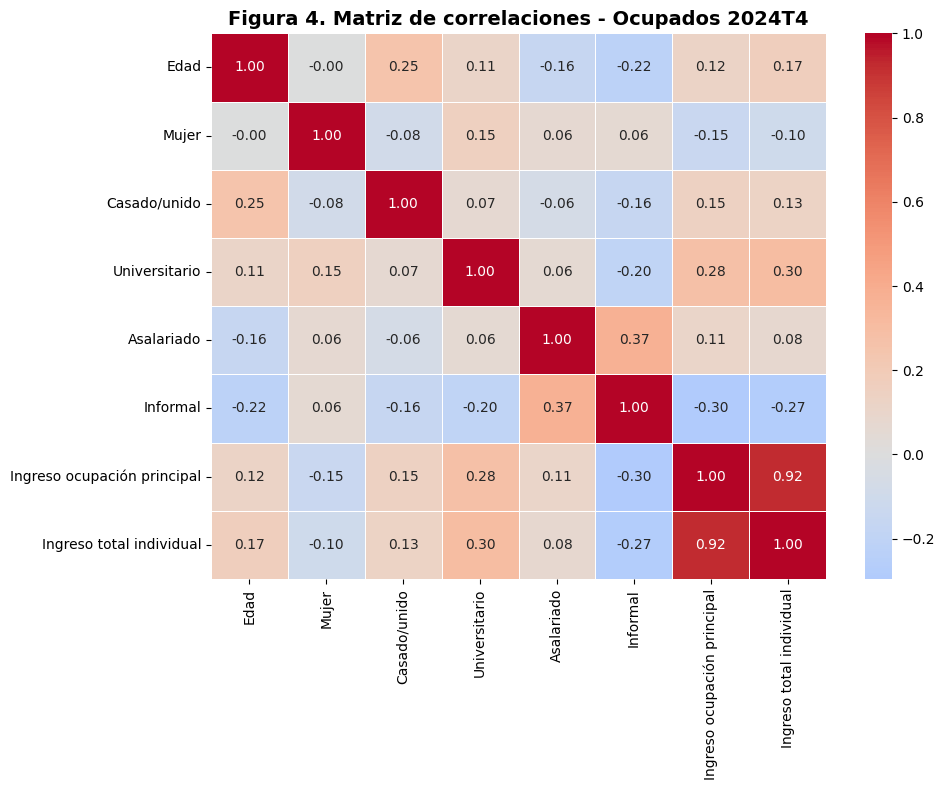

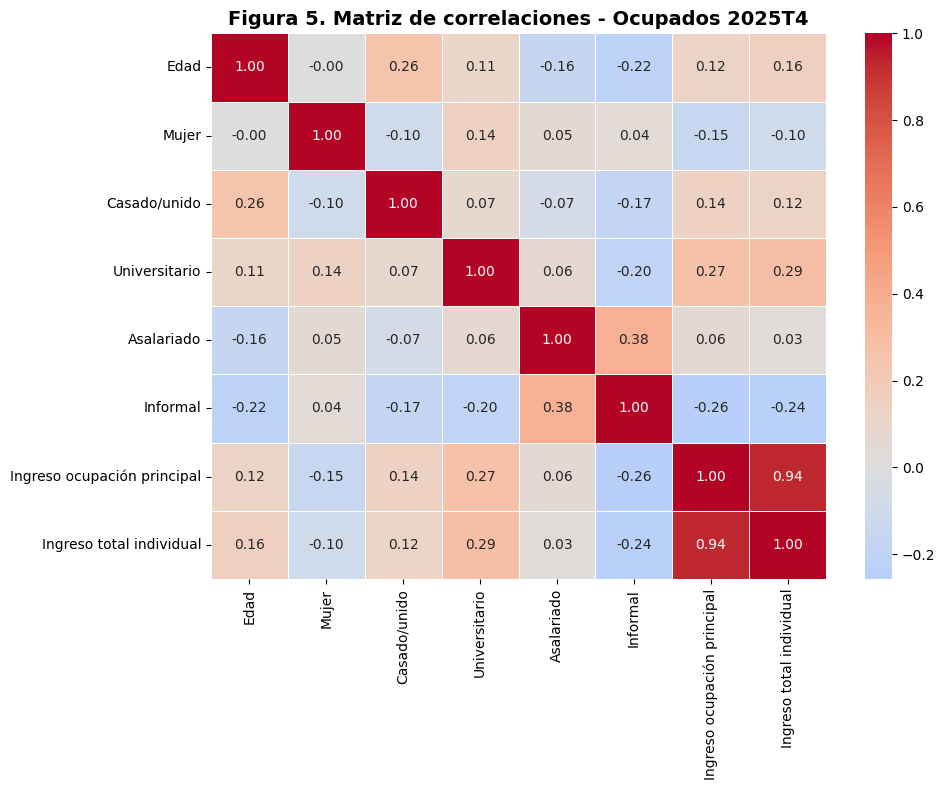

In [45]:
# ============================================================
# 7. MATRICES DE CORRELACIÓN - VERSIÓN CORREGIDA
# ============================================================

# Asegurar variables binarias correctamente construidas
for df in [ocupados24, ocupados25]:
    df["mujer"] = (df["CH04"] == 2).astype(int)
    df["casado"] = df["CH07"].isin([1, 2]).astype(int)   # CORRECTO: CH07, no ESTADO
    df["universitario"] = (df["NIVEL_ED"] >= 6).astype(int)
    df["asalariado"] = (df["CAT_OCUP"] == 3).astype(int)
    df["informal"] = np.where(
        (df["CAT_OCUP"] == 3) & (df["PP07H"] == 2),
        1,
        0
    )

vars_modelo = [
    "CH06",
    "mujer",
    "casado",
    "universitario",
    "asalariado",
    "informal",
    "P21_2025",
    "P47T_2025"
]

nombres = {
    "CH06": "Edad",
    "mujer": "Mujer",
    "casado": "Casado/unido",
    "universitario": "Universitario",
    "asalariado": "Asalariado",
    "informal": "Informal",
    "P21_2025": "Ingreso ocupación principal",
    "P47T_2025": "Ingreso total individual"
}

# -------------------------------
# Matriz de correlación 2024
# -------------------------------

corr24 = ocupados24[vars_modelo].corr().rename(index=nombres, columns=nombres)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr24,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Figura 4. Matriz de correlaciones - Ocupados 2024T4", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("Figura_4_Correlacion_2024.png", dpi=300)
plt.show()

# -------------------------------
# Matriz de correlación 2025
# -------------------------------

corr25 = ocupados25[vars_modelo].corr().rename(index=nombres, columns=nombres)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr25,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Figura 5. Matriz de correlaciones - Ocupados 2025T4", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("Figura_5_Correlacion_2025.png", dpi=300)
plt.show()

## 8. Valores faltantes

In [46]:
# Variables seleccionadas para el análisis

variables = [
    "CH04","CH06","CH07","CH08","NIVEL_ED",
    "ESTADO","CAT_OCUP","PP04C","PP04D_COD",
    "PP07H","PP07I","PP07J","PP07K",
    "PP08D1","PP08F1","P21","P47T"
]

# Porcentaje de valores faltantes

faltantes = pd.DataFrame({
    "Respondieron 2024": respondieron24[variables].isna().mean()*100,
    "Ocupados 2024": respondieron24.loc[
        respondieron24["ESTADO"]==1, variables
    ].isna().mean()*100,
    "Respondieron 2025": respondieron25[variables].isna().mean()*100,
    "Ocupados 2025": respondieron25.loc[
        respondieron25["ESTADO"]==1, variables
    ].isna().mean()*100
})

faltantes = faltantes.round(2)

faltantes

,Respondieron 2024,Ocupados 2024,Respondieron 2025,Ocupados 2025
CH04,0.00,0.00,0.00,0.00
CH06,0.00,0.00,0.00,0.00
CH07,0.00,0.00,0.00,0.00
CH08,0.00,0.00,0.00,0.00
NIVEL_ED,0.00,0.00,0.00,0.00
ESTADO,0.00,0.00,0.00,0.00
CAT_OCUP,0.00,0.00,0.00,0.00
PP04C,54.85,0.00,54.86,0.00
PP04D_COD,54.85,0.00,54.86,0.00
PP07H,54.85,0.00,54.86,0.00


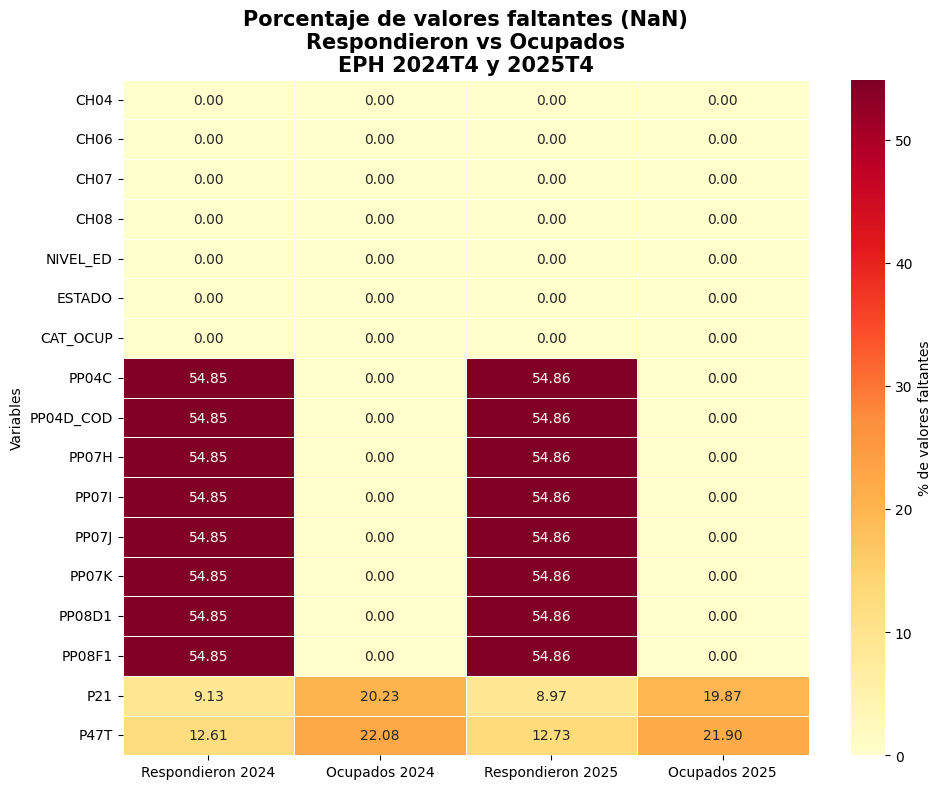

In [47]:
plt.figure(figsize=(10,8))

sns.heatmap(
    faltantes,
    annot=True,
    cmap="YlOrRd",
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label":"% de valores faltantes"}
)

plt.title(
    "Porcentaje de valores faltantes (NaN)\nRespondieron vs Ocupados\nEPH 2024T4 y 2025T4",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Variables")

plt.tight_layout()

plt.savefig(
    "Figura_3_Heatmap_Valores_Faltantes.png",
    dpi=300
)

plt.show()

In [48]:
print("Respondieron 2024 :", len(respondieron24))
print("Ocupados 2024     :", len(ocupados24))
print("Respondieron 2025 :", len(respondieron25))
print("Ocupados 2025     :", len(ocupados25))

Respondieron 2024 : 46804
Ocupados 2024     : 21132
Respondieron 2025 : 43638
Ocupados 2025     : 19698


In [49]:
plt.figtext(
    0.5, -0.02,
    "n Respondieron 2024 = 46.804 | Ocupados 2024 = 21.132 | Respondieron 2025 = 43.638 | Ocupados 2025 = 19.698",
    ha="center",
    fontsize=10
)

Text(0.5, -0.02, 'n Respondieron 2024 = 46.804 | Ocupados 2024 = 21.132 | Respondieron 2025 = 43.638 | Ocupados 2025 = 19.698')

<Figure size 640x480 with 0 Axes>

In [50]:
tabla_final_ajustada_formato = tabla_final_ajustada.copy()

tabla_final_ajustada_formato["2024 ajustado"] = tabla_final_ajustada_formato["2024 ajustado"].map(lambda x: f"{x:,.2f}")
tabla_final_ajustada_formato["2025"] = tabla_final_ajustada_formato["2025"].map(lambda x: f"{x:,.2f}")
tabla_final_ajustada_formato["Variación %"] = tabla_final_ajustada_formato["Variación %"].map(lambda x: f"{x:,.2f}%")

tabla_final_ajustada_formato

,Indicador,2024 ajustado,2025,Variación %
0,Ocupados,"21,132.00","19,698.00",-6.79%
1,Edad promedio,41.31,41.86,1.34%
2,Mujeres (%),45.00,45.49,1.09%
3,Casados/unidos (%),53.54,53.42,-0.22%
4,Universitarios (%),24.39,23.93,-1.92%
5,Asalariados (%),72.36,70.78,-2.18%
6,Informales (%),26.33,26.03,-1.14%
7,Ingreso total promedio ajustado,"940,384.54","1,040,594.84",10.66%


In [51]:
tabla_final_ajustada_formato.to_excel(
    "Tabla_1_Comparativo_2024_2025.xlsx",
    index=False
)

In [52]:
from google.colab import files
files.download("Tabla_1_Comparativo_2024_2025.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [53]:
import os

os.listdir()

['.config',
 'usu_individual_T424 (2).xlsx',
 'Figura_4_Correlacion_2024.png',
 'Tabla_2_Descriptivos_2025.xlsx',
 'usu_individual_T424.xlsx',
 'Figura_5_Correlacion_2025.png',
 'Grafico_Ingresos_2025.png',
 'usu_individual_T425.xlsx',
 'Tabla_3_Comparativo_2024_2025.xlsx',
 'Figura_3_Heatmap_Valores_Faltantes.png',
 'Figura_2_Distribucion_Ingresos_2025.png',
 'usu_individual_T425 (2).xlsx',
 'Tabla_1_Comparativo_2024_2025.xlsx',
 'usu_individual_T425 (1).xlsx',
 'Grafico_Ingresos_2024.png',
 'usu_individual_T424 (1).xlsx',
 'Figura_1_Distribucion_Ingresos_2024.png',
 'Tabla_1_Descriptivos_2024.xlsx',
 'sample_data']

In [54]:
import glob

glob.glob("*.png")

['Figura_4_Correlacion_2024.png',
 'Figura_5_Correlacion_2025.png',
 'Grafico_Ingresos_2025.png',
 'Figura_3_Heatmap_Valores_Faltantes.png',
 'Figura_2_Distribucion_Ingresos_2025.png',
 'Grafico_Ingresos_2024.png',
 'Figura_1_Distribucion_Ingresos_2024.png']

## 9. Exportación de tablas y figuras

In [55]:
# ===============================
# EXPORTAR FIGURAS Y TABLAS TP1
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Variables para descriptivos y correlaciones
vars_modelo = ["CH06", "mujer", "casado", "universitario", "asalariado", "informal", "P21_2025", "P47T_2025"]

nombres = {
    "CH06": "Edad",
    "mujer": "Mujer",
    "casado": "Casado/unido",
    "universitario": "Universitario",
    "asalariado": "Asalariado",
    "informal": "Informal",
    "P21_2025": "Ingreso ocupación principal",
    "P47T_2025": "Ingreso total individual"
}

# -------------------------------
# Tablas descriptivas
# -------------------------------

tabla_desc_2024 = ocupados24[vars_modelo].describe().T
tabla_desc_2025 = ocupados25[vars_modelo].describe().T

tabla_desc_2024 = tabla_desc_2024.rename(index=nombres).round(2)
tabla_desc_2025 = tabla_desc_2025.rename(index=nombres).round(2)

tabla_desc_2024.to_excel("Tabla_1_Descriptivos_2024.xlsx")
tabla_desc_2025.to_excel("Tabla_2_Descriptivos_2025.xlsx")
tabla_final_ajustada.to_excel("Tabla_3_Comparativo_2024_2025.xlsx", index=False)

# -------------------------------
# Verificar archivos generados
# -------------------------------

import glob
archivos_generados = glob.glob("*.png") + glob.glob("*.xlsx")
archivos_generados

['Figura_4_Correlacion_2024.png',
 'Figura_5_Correlacion_2025.png',
 'Grafico_Ingresos_2025.png',
 'Figura_3_Heatmap_Valores_Faltantes.png',
 'Figura_2_Distribucion_Ingresos_2025.png',
 'Grafico_Ingresos_2024.png',
 'Figura_1_Distribucion_Ingresos_2024.png',
 'usu_individual_T424 (2).xlsx',
 'Tabla_2_Descriptivos_2025.xlsx',
 'usu_individual_T424.xlsx',
 'usu_individual_T425.xlsx',
 'Tabla_3_Comparativo_2024_2025.xlsx',
 'usu_individual_T425 (2).xlsx',
 'Tabla_1_Comparativo_2024_2025.xlsx',
 'usu_individual_T425 (1).xlsx',
 'usu_individual_T424 (1).xlsx',
 'Tabla_1_Descriptivos_2024.xlsx']

# Exportación automática de tablas y figuras

In [56]:
for archivo in archivos_generados:
    files.download(archivo)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Fin del Trabajo Práctico

Todas las tablas, gráficos y resultados presentados en el informe fueron generados mediante este notebook.

Repositorio GitHub:
https://github.com/PabloTallerProgramacion/TP1_Programacion_UBA.git